# 01｜Token、Embedding 与三维张量

Transformer 不直接读取“红色”文字。先把 token 映射成整数，再把每个整数查表变成一个向量。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "transformer_lab").is_dir():
    LAB_DIR = (LAB_DIR / "04_transformer_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

# 共享服务器约定：一个 Notebook 只占一个 CPU 线程。
torch.set_num_threads(1)

from transformer_lab import (
    TinyTransformerClassifier, make_retrieval_data,
    plot_tensor_structure, plot_token_sequence,
)


## 第一步：看 token id

本实验词表只有 4 项：`红=0`、`绿=1`、`蓝=2`、`QUERY=3`。第一维是 Batch，第二维是 token 位置。

训练输入 shape [N,T]： (120, 13)
训练标签 shape [N]： (120,)
词表： {0: '红', 1: '绿', 2: '蓝', 3: '查询'}


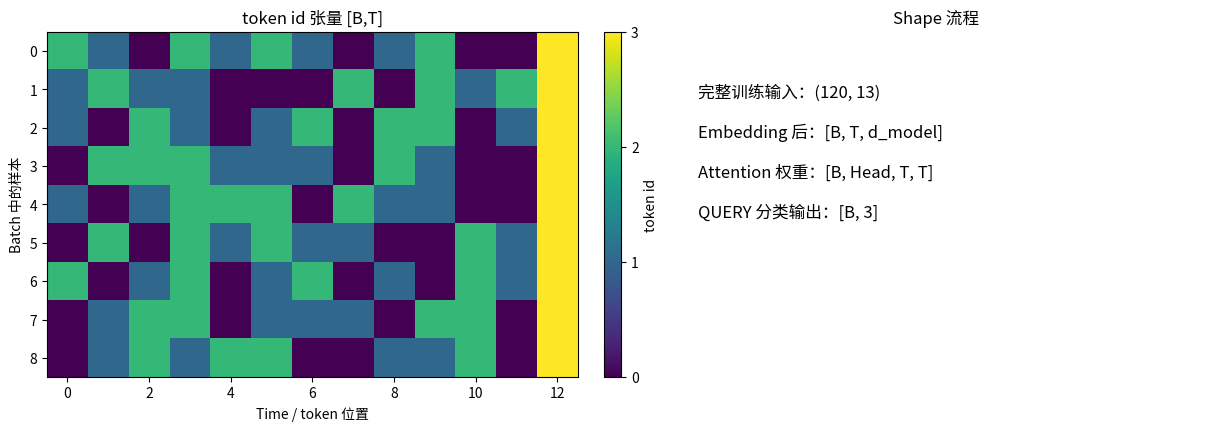

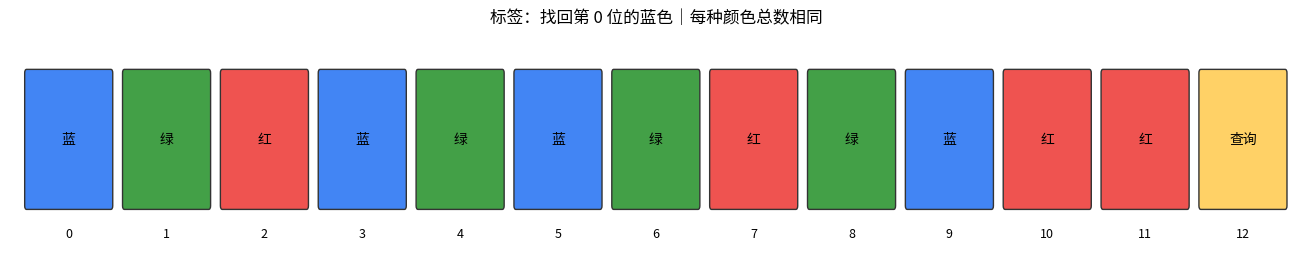

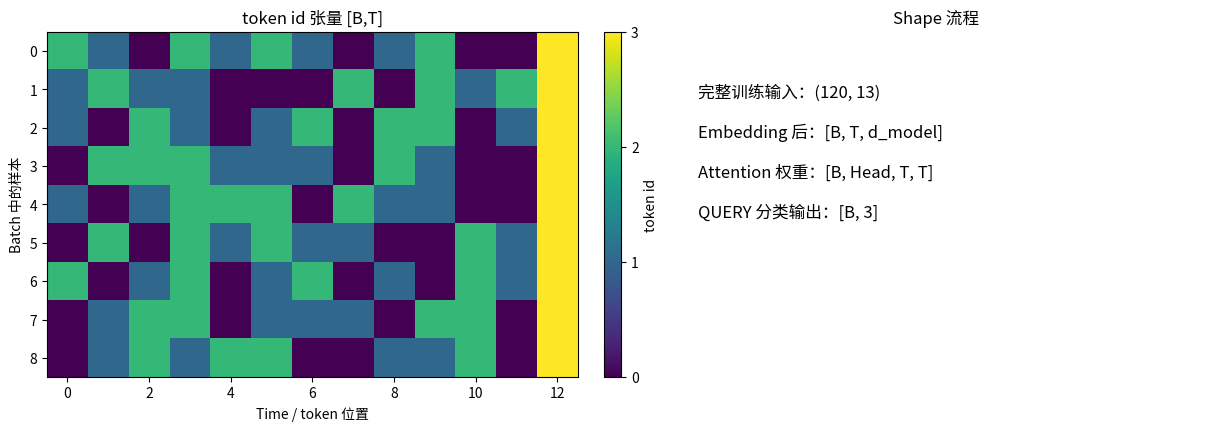

In [2]:
data = make_retrieval_data(
    content_length=12, train_size=120, val_size=30, test_size=30, seed=42
)
print("训练输入 shape [N,T]：", tuple(data.x_train.shape))
print("训练标签 shape [N]：", tuple(data.y_train.shape))
print("词表：", dict(enumerate(data.token_names)))

plot_token_sequence(data.x_train, data.y_train, index=0)
plot_tensor_structure(data)


## 第二步：检查“不能靠计数作弊”

第 0 位决定标签，但每条序列的红、绿、蓝总数都相同。训练、验证、测试也不能包含完全相同的 token 序列。

In [3]:
sample = data.x_train[0]
counts = [(sample[:-1] == token_id).sum().item() for token_id in range(3)]
print("红、绿、蓝计数：", counts)
print("第 0 位 token id：", int(sample[0]), "｜标签：", int(data.y_train[0]))

as_rows = lambda tensor: {tuple(row.tolist()) for row in tensor}
train_rows, val_rows, test_rows = map(
    as_rows, (data.x_train, data.x_val, data.x_test)
)
print("训练∩验证：", len(train_rows & val_rows))
print("训练∩测试：", len(train_rows & test_rows))
print("验证∩测试：", len(val_rows & test_rows))


红、绿、蓝计数： [4, 4, 4]
第 0 位 token id： 2 ｜标签： 2
训练∩验证： 0
训练∩测试： 0
验证∩测试： 0


## 第三步：Embedding 把 `[B,T]` 变成 `[B,T,D]`

Embedding 是一张可训练查找表。同一个 token 在不同样本中使用同一行参数；位置编码随后再告诉模型“它出现在哪里”。

In [4]:
model = TinyTransformerClassifier(
    d_model=16, num_heads=4, num_layers=1,
    dim_feedforward=32, dropout=0.0,
)
batch_ids = data.x_train[:8]
embedded = model.embedding(batch_ids)

print("token ids：", tuple(batch_ids.shape), "dtype =", batch_ids.dtype)
print("Embedding 权重：", tuple(model.embedding.weight.shape))
print("Embedding 输出：", tuple(embedded.shape))
print("Attention 后仍保持 [B,T,D]，分类头最终输出 [B,3]：",
      tuple(model(batch_ids).shape))


token ids： (8, 13) dtype = torch.int64
Embedding 权重： (4, 16)
Embedding 输出： (8, 13, 16)
Attention 后仍保持 [B,T,D]，分类头最终输出 [B,3]： (8, 3)


## 填写 shape 通行证

- 单条序列：`[T] = [__]`
- 8 条序列：`[B,T] = [__,__]`
- Embedding 后：`[B,T,D] = [__,__,__]`
- 4 个 Head 的 Attention：`[B,H,T,T] = [__,__,__,__]`
- 分类 logits：`[B,3] = [__,3]`

不要把 token id 的数值大小解释为颜色之间的距离；它只是查表索引。

## 完成本页后：释放资源并结束内核

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)
